# Contour Chart

This section showcases the contour chart. It contains examples of how to create contour charts using the [datachart.charts.ContourChart](../../../references/charts/#datachart.charts.ContourChart) function.

Looking for a specific customization? Jump straight to the [quick reference](#customizing-the-contour-chart), which maps common tasks to the parameter or style attribute that does the job.

As mentioned above, the contour charts are created using the `ContourChart` function found in the [datachart.charts](../../../references/charts/) module. Let's import it:

In [1]:
from datachart.charts import ContourChart

## Contour Chart Input Attributes

The `ContourChart` function accepts keyword arguments for chart configuration. The main argument is `data`, which contains the gridded surface. For a single contour chart, `data` is a dictionary with the 2-D `z` grid and the optional `x` and `y` axis values; for multiple contour charts, `data` is a list of such dictionaries.

```python
ContourChart(
    data={                                              # The gridded surface (or list of surfaces for multiple charts)
        "x": Union[List[Union[int, float]], None],      # The x-axis values, one per column of z (the column indices by default)
        "y": Union[List[Union[int, float]], None],      # The y-axis values, one per row of z (the row indices by default)
        "z": List[List[Union[int, float]]],             # The 2-D grid of surface values, one row per y and one column per x
    },
    style={                                             # The style of the contour chart (optional)
        "plot_contour_color":           Optional[str],  # The iso-line color (the panel's color cycle by default)
        "plot_contour_cmap":            Optional[Union[str, List[str]]], # The colormap of the filled bands (the heatmap colormap by default)
        "plot_contour_line_width":      Optional[Union[int, float]], # The iso-line width (the line chart width by default)
        "plot_contour_line_style":      Optional[str],  # The iso-line style
        "plot_contour_alpha":           Optional[float], # The alpha of the contour
        "plot_contour_zorder":          Optional[Union[int, float]], # The z-order of the contour
        "plot_contour_label_font_size": Optional[Union[int, float]], # The font size of the inline level labels
        "plot_contour_label_font_color": Optional[str], # The color of the inline level labels (the line color by default)
    },
    title: Optional[str],                               # The title of the chart
    xlabel: Optional[str],                              # The x-axis label
    ylabel: Optional[str],                              # The y-axis label
    subtitle: Optional[Union[str, List[str]]],          # The subtitle(s), also used as legend labels
    emphasis: Optional[Union[str, List[Optional[str]]]], # The emphasis role(s) of the iso-lines ("background", "highlight", None)
    figsize: Optional[Tuple[float, float]],             # The size of the figure
    xmin: Optional[Union[int, float]],                  # The minimum x-axis value
    xmax: Optional[Union[int, float]],                  # The maximum x-axis value
    ymin: Optional[Union[int, float]],                  # The minimum y-axis value
    ymax: Optional[Union[int, float]],                  # The maximum y-axis value
    show_legend: Optional[bool],                        # Whether to show the legend
    show_grid: Optional[str],                           # Which grid lines to show ("both", "x", "y"); off by default for filled contours
    filled: Optional[bool],                             # Whether to fill the bands between the levels instead of drawing iso-lines
    levels: Optional[Union[str, int, List[float]]],     # The level rule ("auto", "rice", "fd"), a target count, or explicit level values
    show_labels: Optional[bool],                        # Whether to write the level values along the iso-lines
    show_colorbars: Optional[bool],                     # Whether to show the colorbar of filled contours
    aspect_ratio: Optional[str],                        # The aspect ratio of the axes ("auto", "equal")
    scalex: Optional[str],                              # The x-axis scale ("linear", "log", ...)
    scaley: Optional[str],                              # The y-axis scale ("linear", "log", ...)
    subplots: Optional[bool],                           # Whether to create a separate subplot for each chart
    max_cols: Optional[int],                            # The maximum number of columns in the subplots
    sharex: Optional[bool],                             # Whether to share the x-axis across the subplots
    sharey: Optional[bool],                             # Whether to share the y-axis across the subplots
    norm: Optional[Union[str, List[str]]],              # The value normalization of the colormap
    vmin: Optional[Union[float, List[float]]],          # The minimum value of the colormap range
    vmax: Optional[Union[float, List[float]]],          # The maximum value of the colormap range
    valfmt: Optional[Union[str, List[str]]],            # The format of the inline level labels (e.g. "{x:.1f}")
    xticks: Optional[List[Union[int, float]]],          # The x-axis tick positions
    xticklabels: Optional[List[str]],                   # The x-axis tick labels
    xtickrotate: Optional[int],                         # The rotation of the x-axis tick labels
    yticks: Optional[List[Union[int, float]]],          # The y-axis tick positions
    yticklabels: Optional[List[str]],                   # The y-axis tick labels
    ytickrotate: Optional[int],                         # The rotation of the y-axis tick labels
    vlines: Optional[Union[dict, List[dict]]],          # The vertical reference lines
    hlines: Optional[Union[dict, List[dict]]],          # The horizontal reference lines
    colorbar: Optional[Union[dict, List[dict]]],        # The colorbar configuration(s) ({"orientation": ...})
    texts: Optional[Union[dict, List[dict]]],           # The text annotations
)
```

For more details, see the [datachart.charts.ContourChart](../../../references/charts/#datachart.charts.ContourChart) function.

## Basics

The examples in this guide share one surface: the [Himmelblau function](https://en.wikipedia.org/wiki/Himmelblau%27s_function), a classic test surface for optimization algorithms with four minima of equal depth and one local maximum between them. `chart_data` samples it on a 120×120 grid over the −5 … 5 square: `x` and `y` hold the grid coordinates and `z` the function value at every grid point, one row per `y` and one column per `x`.

In [2]:
import numpy as np

GRID = np.linspace(-5, 5, 120)
X, Y = np.meshgrid(GRID, GRID)
# the Himmelblau function, sampled on the grid
himmelblau = (X**2 + Y - 11) ** 2 + (X + Y**2 - 7) ** 2

chart_data = {"x": GRID.tolist(), "y": GRID.tolist(), "z": himmelblau.tolist()}

The data is a dictionary with the grid coordinates and the surface. The `z` grid is a list of rows, one per `y` value, and each row holds one value per `x` value; `x` and `y` are optional — without them the grid is drawn over its cell indices:

In [3]:
[len(chart_data["x"]), len(chart_data["y"]), len(chart_data["z"]), len(chart_data["z"][0])]

[120, 120, 120, 120]

**Basic example.** Only the `data` argument is required to draw the contour chart. The surface is cut at a handful of round values and every cut is drawn as an iso-line — a line of equal value, like the elevation lines of a map. The lines take the chart's color, so a lone contour chart matches a lone line chart; closed loops mark the minima and maxima of the surface.

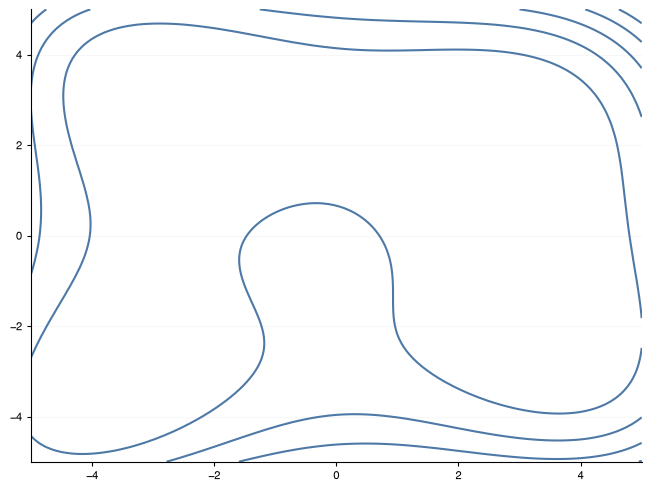

In [4]:
ContourChart(
    # add the data to the chart
    data=chart_data
).show()

## Customizing the Contour Chart

Every customization is either a keyword argument of `ContourChart` or a `plot_contour_*` attribute of its `style` dictionary. The table maps common tasks to the one you need and links to the subsection that shows it.

| I want to…                                  | Use                                                                     | See |
| :------------------------------------------ | :---------------------------------------------------------------------- | :-- |
| add a title and axis labels                 | `title`, `xlabel`, `ylabel`                                             | [Title and axis labels](#title-and-axis-labels) |
| resize the figure                           | `figsize`                                                               | [Figure size and grid](#figure-size-and-grid) |
| show or hide the grid lines                 | `show_grid`                                                             | [Figure size and grid](#figure-size-and-grid) |
| fill the bands between the levels           | `filled=True`                                                           | [Filled contours and colorbar](#filled-contours-and-colorbar) |
| add a colorbar                              | `show_colorbars=True`, `colorbar={"orientation": ...}`                  | [Filled contours and colorbar](#filled-contours-and-colorbar) |
| write the level values on the lines         | `show_labels=True`, `valfmt`                                            | [Inline labels](#inline-labels) |
| choose how many levels cut the surface      | `levels`                                                                | [Levels](#levels) |
| change the line color, width, or style      | `style={"plot_contour_color": ..., "plot_contour_line_width": ...}`     | [Contour style](#contour-style) |
| change the colormap of the fills            | `style={"plot_contour_cmap": ...}`                                      | [Contour style](#contour-style) |
| pin or rescale the colormap range           | `vmin`, `vmax`, `norm`                                                  | [Normalization](#normalization) |
| overlay several surfaces                    | `data=[...]`, `subtitle`, `show_legend`                                 | [Multiple Contour Charts](#multiple-contour-charts) |
| draw each surface in its own subplot        | `subplots=True`, `max_cols`, `sharex`, `sharey`                         | [Subplots and shared axes](#subplots-and-shared-axes) |
| highlight one surface among several         | `emphasis`                                                              | [Emphasis](#emphasis) |
| draw the contours over a scatter chart      | `Panel`                                                                 | [Composing contours](#composing-contours) |
| keep one unit equal on both axes            | `aspect_ratio`                                                          | [Aspect ratio](#aspect-ratio) |
| mark a position with a reference line       | `vlines`, `hlines`                                                      | [Reference lines](#reference-lines) |
| estimate the density of scattered points    | `stats.kde2d`, `bandwidth`                                              | [Density of scattered points](#density-of-scattered-points) |

### Title and axis labels

To add the chart title and axis labels, add the `title`, `xlabel` and `ylabel` attributes.

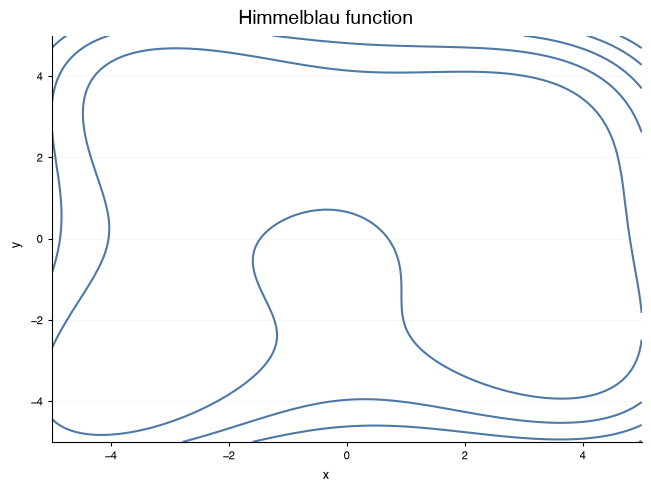

In [5]:
ContourChart(
    data=chart_data,
    # add the title
    title="Himmelblau function",
    # add the x and y axis labels
    xlabel="x",
    ylabel="y",
).show()

### Figure size and grid

To change the figure size, add the `figsize` attribute. The `figsize` attribute can be a tuple (width, height), values are in inches. The `datachart` package provides a [datachart.constants.FIG_SIZE](../../../references/constants/#datachart.constants.FIG_SIZE) constant, which contains predefined figure sizes. To change which grid lines are shown, add the `show_grid` attribute, which supports the values of the [datachart.constants.SHOW_GRID](../../../references/constants/#datachart.constants.SHOW_GRID) constant — iso-lines draw over the theme's default grid, so both axes can be gridded to read positions off the lines.

In [6]:
from datachart.constants import FIG_SIZE, SHOW_GRID

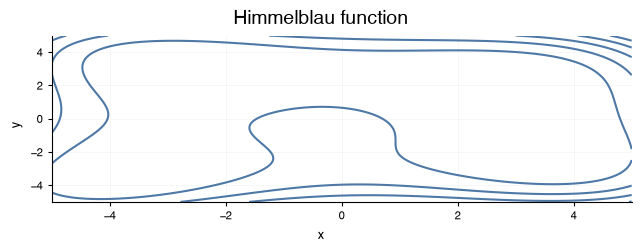

In [7]:
ContourChart(
    data=chart_data,
    title="Himmelblau function",
    xlabel="x",
    ylabel="y",
    # add to determine the figure size
    figsize=FIG_SIZE.FULL_SHORT,
    # add to show the grid lines on both axes
    show_grid=SHOW_GRID.BOTH,
).show()

### Filled contours and colorbar

To fill the bands between the levels instead of drawing iso-lines, add the `filled` attribute. A filled contour colors every band by its value with the colormap — the heatmap colormap by default — so the low and the high regions of the surface read at a glance; the grid is left off, as the bands would cover it. To map the colors back to values, add the `show_colorbars` attribute, which draws the colorbar to the right of the chart; to draw it horizontally instead, add the `colorbar` attribute with the [datachart.typings.HeatmapColorbarAttrs](../../../references/typings/#datachart.typings.HeatmapColorbarAttrs) typing, whose `orientation` takes a value of the [datachart.constants.ORIENTATION](../../../references/constants/#datachart.constants.ORIENTATION) constant.

In [8]:
from datachart.constants import ORIENTATION

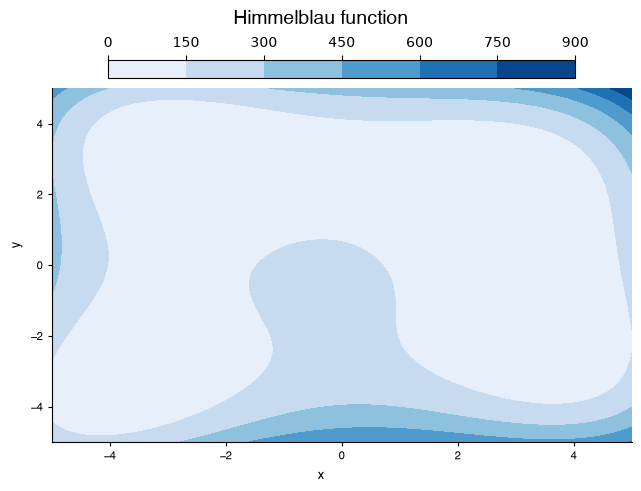

In [9]:
ContourChart(
    data=chart_data,
    # fill the bands between the levels
    filled=True,
    # add the colorbar, drawn above the chart
    show_colorbars=True,
    colorbar={"orientation": ORIENTATION.HORIZONTAL},
    title="Himmelblau function",
    xlabel="x",
    ylabel="y",
    figsize=FIG_SIZE.FULL_MEDIUM,
).show()

### Inline labels

To write the value of every level along its iso-line, add the `show_labels` attribute. The labels are formatted by the `valfmt` attribute, a format string with the value named `x` (e.g. `"{x:.1f}"`); the [datachart.constants.VALUE_FORMAT](../../../references/constants/#datachart.constants.VALUE_FORMAT) constant holds the common ones. The labels take the line color and a font two points smaller than the general font, which the `plot_contour_label_font_size` and `plot_contour_label_font_color` style attributes override.

In [10]:
from datachart.constants import VALUE_FORMAT

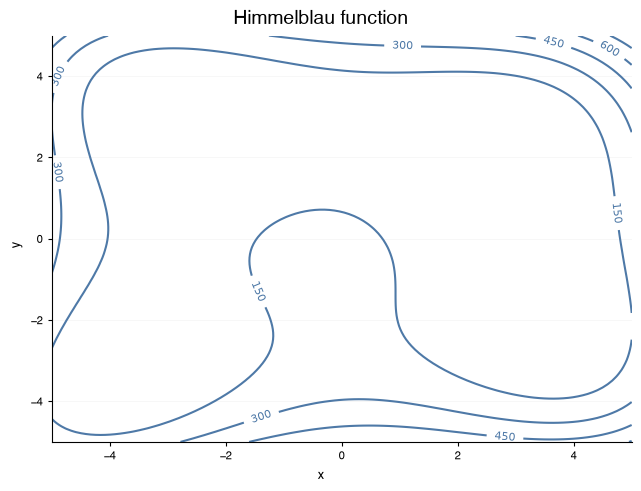

In [11]:
ContourChart(
    data=chart_data,
    # write the level values along the lines, as integers
    show_labels=True,
    valfmt=VALUE_FORMAT.INTEGER,
    title="Himmelblau function",
    xlabel="x",
    ylabel="y",
    figsize=FIG_SIZE.FULL_MEDIUM,
).show()

### Levels

The `levels` attribute chooses which values cut the surface. It takes one of the following:

| Value | Description |
| :---- | :---------- |
| `"auto"` | Matplotlib's own choice: about eight round values across the range of the surface (the default). |
| `"rice"` | The Rice rule: `2 * n ** (1/3)` levels, where `n` is the per-axis resolution of the grid — about ten levels on a 120×120 grid. |
| `"fd"` | The Freedman–Diaconis rule: the value range over `2 * IQR * n ** (-1/3)` — about twice as dense as Rice on the same grid. |
| an integer | A target number of levels, snapped to round values. |
| a list | The exact level values to draw. |

The `datachart` package provides the [datachart.constants.CONTOUR_LEVELS](../../../references/constants/#datachart.constants.CONTOUR_LEVELS) constant with the rules. The rules follow the grid resolution rather than the surface, so they are opt-ins; for a surface whose range spans orders of magnitude, an explicit list of levels is usually the best choice.

In [12]:
from datachart.constants import CONTOUR_LEVELS

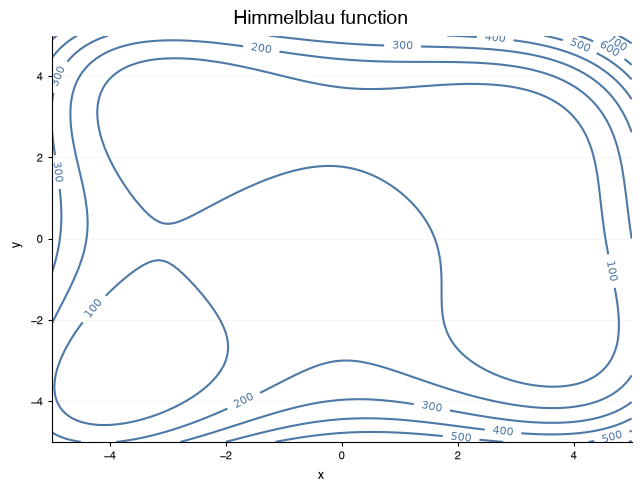

In [13]:
ContourChart(
    data=chart_data,
    # cut the surface by the Rice rule
    levels=CONTOUR_LEVELS.RICE,
    show_labels=True,
    valfmt=VALUE_FORMAT.INTEGER,
    title="Himmelblau function",
    xlabel="x",
    ylabel="y",
    figsize=FIG_SIZE.FULL_MEDIUM,
).show()

The Himmelblau function is flat around its minima and steep at the corners, so evenly spaced levels crowd the corners and leave the middle empty. A list of hand-picked levels, dense near zero and sparse further up, follows the shape of the surface instead:

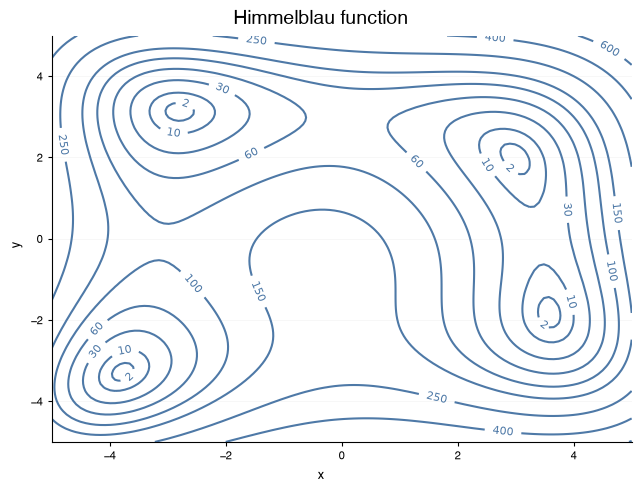

In [14]:
ContourChart(
    data=chart_data,
    # explicit levels: dense near the minima, sparse up the slopes
    levels=[2, 10, 30, 60, 100, 150, 250, 400, 600],
    show_labels=True,
    valfmt=VALUE_FORMAT.INTEGER,
    title="Himmelblau function",
    xlabel="x",
    ylabel="y",
    figsize=FIG_SIZE.FULL_MEDIUM,
).show()

### Contour style

To change the contour style, add the `style` attribute with the corresponding attributes. The supported attributes are shown in the [datachart.typings.ContourStyleAttrs](../../../references/typings/#datachart.typings.ContourStyleAttrs) type, which contains the following attributes:

| Attribute                         | Description |
| :-------------------------------- | :---------- |
| `"plot_contour_color"`            | The color of the iso-lines; the panel's color cycle by default. |
| `"plot_contour_cmap"`             | The colormap of the filled bands (a palette name or a list of hex colors); the heatmap colormap by default. Iso-lines take it only when it is set, colored by level from its darker part. |
| `"plot_contour_line_width"`       | The width of the iso-lines; the line chart width by default. |
| `"plot_contour_line_style"`       | The style of the iso-lines (solid, dashed, ...). |
| `"plot_contour_alpha"`            | The alpha of the contour (how visible it is). |
| `"plot_contour_zorder"`           | The z-order of the contour among the other layers. |
| `"plot_contour_label_font_size"`  | The font size of the inline level labels. |
| `"plot_contour_label_font_color"` | The color of the inline level labels; the line color by default. |

The `datachart` package provides the [datachart.constants.LINE_STYLE](../../../references/constants/#datachart.constants.LINE_STYLE) constant with the line styles and the [datachart.constants.COLORS](../../../references/constants/#datachart.constants.COLORS) constant with the colormaps.

In [15]:
from datachart.constants import COLORS, LINE_STYLE

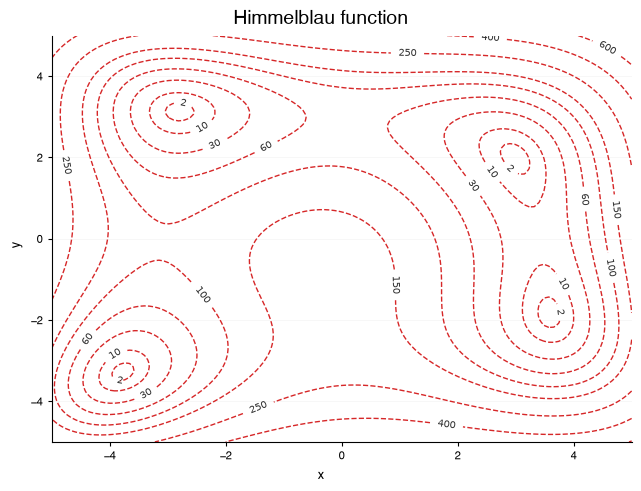

In [16]:
ContourChart(
    data=chart_data,
    # define the style of the contour
    style={
        "plot_contour_color": "#d62728",
        "plot_contour_line_width": 1.0,
        "plot_contour_line_style": LINE_STYLE.DASHED,
        "plot_contour_label_font_size": 7,
        "plot_contour_label_font_color": "#333333",
    },
    levels=[2, 10, 30, 60, 100, 150, 250, 400, 600],
    show_labels=True,
    valfmt=VALUE_FORMAT.INTEGER,
    title="Himmelblau function",
    xlabel="x",
    ylabel="y",
    figsize=FIG_SIZE.FULL_MEDIUM,
).show()

With a colormap set, the iso-lines are colored by their level instead of drawing in one color — the low levels in the lighter shades, the high ones in the darker. The colormap is sampled from its darker part, since the lightest shades of a sequential colormap would vanish on the white background:

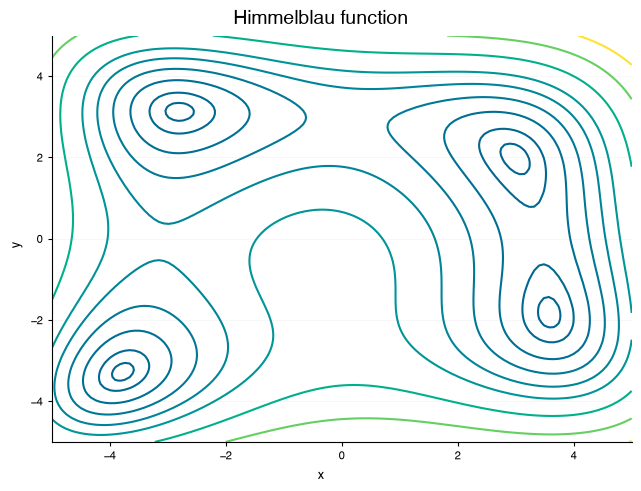

In [17]:
ContourChart(
    data=chart_data,
    # color the iso-lines by level
    style={"plot_contour_cmap": COLORS.Viridis},
    levels=[2, 10, 30, 60, 100, 150, 250, 400, 600],
    title="Himmelblau function",
    xlabel="x",
    ylabel="y",
    figsize=FIG_SIZE.FULL_MEDIUM,
).show()

### Normalization

The colors of a filled contour come from a two-step mapping: the level values are first normalized to the 0–1 range, then each normalized value picks its color from the colormap. Both steps can be adjusted.

**Value range.** By default the lowest level maps to the first color and the highest to the last. The `vmin` and `vmax` attributes pin those endpoints instead, which keeps the shades comparable across charts of the same quantity.

**Normalization.** The `norm` attribute changes how the values are spread over the 0–1 range; the options are the values of the [datachart.constants.NORMALIZE](../../../references/constants/#datachart.constants.NORMALIZE) constant (`"linear"`, `"log"`, `"symlog"`, `"asinh"`, `"logit"`). The Himmelblau function ranges from 0 to about 900 while its interesting part sits below 50: with log-spaced levels and the log normalization every band takes an equally distinct shade, where the linear normalization would spend most of the colormap on the empty corners.

In [18]:
from datachart.constants import NORMALIZE

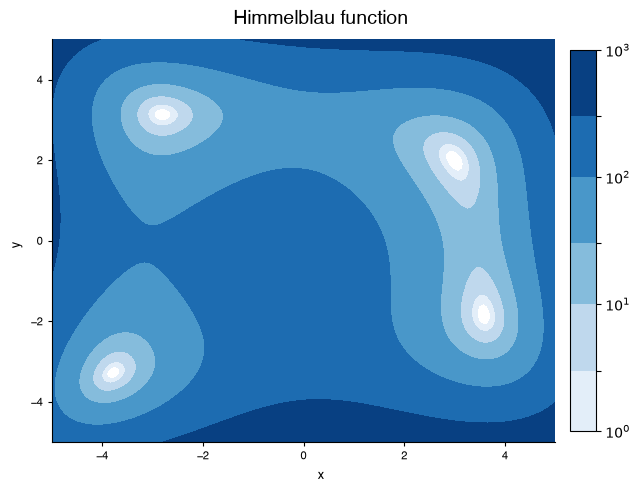

In [19]:
ContourChart(
    data=chart_data,
    filled=True,
    show_colorbars=True,
    # log-spaced levels, spread evenly over the colormap
    levels=[1, 3, 10, 30, 100, 300, 1000],
    norm=NORMALIZE.LOG,
    title="Himmelblau function",
    xlabel="x",
    ylabel="y",
    figsize=FIG_SIZE.FULL_MEDIUM,
).show()

## Multiple Contour Charts

To create multiple contour charts, pass a list of surfaces to the `data` argument. Each surface is drawn as its own set of iso-lines on the same axes, in its own color, and the `subtitle` of each chart becomes its legend label; `subplots=True` draws each surface in its own subplot instead. Several filled contours would cover each other, so fills are best kept to subplots.

`species_density` holds three surfaces from the [Palmer penguins](https://allisonhorst.github.io/palmerpenguins/) dataset (CC0): the density of the 342 penguins of each species over their flipper length and body mass, estimated by [datachart.utils.stats.kde2d](../../../references/utils/stats/#datachart.utils.stats.kde2d) on one shared 80×80 grid and scaled to penguins per mm of flipper length and kg of body mass (see [Density of scattered points](#density-of-scattered-points)). The data is hard-coded in a hidden cell, which also keeps every penguin as a point in `penguin_points` for the later sections.

In [20]:
# the 342 Palmer penguins with a recorded body mass, grouped by species and sex
PENGUINS = [
    {
        "species": "Adelie",
        "sex": "Female",
        "body_mass": [
            3800, 3250, 3450, 3625, 3200, 3700, 3450, 3325, 3400, 3800, 3800, 3200, 3150,
            3250, 3300, 3325, 3550, 3300, 3150, 3100, 3000, 3450, 3500, 3450, 2900, 3550,
            2850, 3150, 3600, 2850, 3350, 3050, 3600, 3550, 3700, 3700, 3550, 3200, 3800,
            3350, 3500, 3600, 3550, 3400, 3300, 3700, 2900, 3725, 3075, 2925, 3750, 3175,
            3825, 3200, 3900, 2900, 3350, 3150, 3450, 3050, 3275, 3050, 3325, 3500, 3425,
            3175, 3400, 3400, 3050, 3000, 3475, 3450, 3700,
        ],
        "flipper_length": [
            186, 195, 193, 181, 182, 185, 195, 184, 174, 189, 187, 187, 172, 178, 188, 195,
            180, 181, 182, 186, 185, 190, 186, 190, 187, 186, 181, 185, 185, 184, 195, 190,
            190, 196, 190, 191, 187, 189, 187, 191, 189, 190, 202, 185, 187, 190, 178, 192,
            183, 193, 199, 181, 198, 193, 191, 188, 189, 187, 176, 186, 191, 191, 190, 193,
            187, 191, 185, 193, 188, 192, 184, 195, 187,
        ],
    },
    {
        "species": "Adelie",
        "sex": "Male",
        "body_mass": [
            3750, 3650, 4675, 3800, 4400, 4500, 4200, 3600, 3950, 3800, 3550, 3950, 3900,
            3900, 4150, 3950, 4650, 3900, 4400, 4600, 3425, 4150, 4300, 4050, 3700, 3800,
            3750, 4400, 4050, 3950, 4100, 4450, 3900, 4150, 4250, 3900, 4000, 4700, 4200,
            3550, 3800, 3950, 4300, 4450, 4300, 4350, 4100, 4725, 4250, 3550, 3900, 4775,
            4600, 4275, 4075, 3775, 3325, 3500, 3875, 4000, 4300, 4000, 3500, 4475, 3900,
            3975, 4250, 3475, 3725, 3650, 4250, 3750, 4000,
        ],
        "flipper_length": [
            181, 190, 195, 191, 198, 197, 194, 180, 185, 180, 183, 180, 178, 184, 196, 190,
            184, 195, 196, 190, 182, 191, 188, 200, 191, 193, 194, 195, 192, 192, 188, 198,
            190, 197, 195, 184, 195, 196, 193, 194, 190, 189, 205, 186, 208, 196, 192, 203,
            190, 184, 190, 197, 191, 197, 196, 199, 189, 198, 202, 199, 195, 210, 197, 199,
            190, 200, 193, 187, 190, 185, 190, 193, 201,
        ],
    },
    {
        "species": "Adelie",
        "sex": None,
        "body_mass": [
            3475, 4250, 3300, 3700, 2975,
        ],
        "flipper_length": [
            193, 190, 186, 180, 179,
        ],
    },
    {
        "species": "Chinstrap",
        "sex": "Female",
        "body_mass": [
            3500, 3525, 3950, 3250, 4150, 3800, 3700, 3575, 3700, 3450, 3600, 2900, 3300,
            3400, 3700, 3200, 3350, 3900, 3850, 2700, 3650, 3500, 3675, 3400, 3675, 3325,
            3600, 3350, 3250, 3525, 3650, 3650, 3400, 3775,
        ],
        "flipper_length": [
            192, 188, 198, 178, 195, 193, 185, 190, 181, 190, 181, 187, 195, 200, 191, 187,
            187, 199, 195, 192, 187, 196, 196, 190, 198, 199, 193, 187, 191, 194, 189, 195,
            202, 198,
        ],
    },
    {
        "species": "Chinstrap",
        "sex": "Male",
        "body_mass": [
            3900, 3650, 3725, 3750, 3700, 3775, 4050, 4050, 3300, 4400, 3400, 3800, 4150,
            3800, 4550, 4300, 4100, 3600, 4800, 4500, 3950, 3550, 4450, 4300, 3250, 3950,
            4050, 3450, 4050, 3800, 3950, 4000, 3775, 4100,
        ],
        "flipper_length": [
            196, 193, 197, 197, 198, 194, 201, 201, 197, 195, 191, 193, 197, 200, 205, 201,
            203, 195, 210, 205, 210, 196, 201, 212, 187, 201, 203, 197, 203, 202, 206, 207,
            193, 210,
        ],
    },
    {
        "species": "Gentoo",
        "sex": "Female",
        "body_mass": [
            4500, 4450, 4550, 4800, 4400, 4650, 4650, 4200, 4150, 4800, 5000, 4400, 5000,
            4600, 4700, 5050, 5150, 4950, 4350, 3950, 4300, 4900, 4200, 5100, 4850, 4400,
            4900, 4300, 4450, 4200, 4400, 4700, 4700, 4750, 5200, 4700, 4600, 4750, 4625,
            4725, 4750, 4600, 4875, 4950, 4750, 4850, 4875, 4625, 4850, 4975, 4700, 4575,
            5000, 4650, 4375, 4925, 4850, 5200,
        ],
        "flipper_length": [
            211, 210, 210, 211, 209, 214, 214, 210, 210, 209, 215, 213, 215, 210, 209, 207,
            220, 213, 208, 208, 210, 217, 210, 213, 210, 210, 217, 208, 208, 208, 214, 219,
            220, 216, 217, 216, 209, 215, 212, 212, 212, 218, 212, 218, 212, 214, 222, 203,
            219, 215, 210, 208, 216, 213, 217, 214, 215, 212,
        ],
    },
    {
        "species": "Gentoo",
        "sex": "Male",
        "body_mass": [
            5700, 5700, 5400, 5200, 5150, 5550, 5850, 5850, 6300, 5350, 5700, 5050, 5100,
            5650, 5550, 5250, 6050, 5400, 5250, 5350, 5700, 4750, 5550, 5400, 5300, 5300,
            5000, 5050, 5000, 5550, 5300, 5650, 5700, 5800, 5550, 5000, 5100, 5800, 6000,
            5950, 5450, 5350, 5600, 5300, 5550, 5400, 5650, 5200, 4925, 5250, 5600, 5500,
            5500, 5500, 5500, 5950, 5500, 5850, 6000, 5750, 5400,
        ],
        "flipper_length": [
            230, 218, 215, 219, 215, 216, 213, 217, 221, 222, 218, 215, 215, 215, 220, 222,
            230, 220, 219, 208, 225, 216, 222, 225, 215, 220, 225, 220, 220, 224, 221, 231,
            230, 229, 223, 221, 221, 230, 220, 223, 221, 224, 228, 218, 230, 228, 224, 226,
            216, 225, 228, 228, 215, 219, 209, 229, 230, 230, 222, 222, 213,
        ],
    },
    {
        "species": "Gentoo",
        "sex": None,
        "body_mass": [
            4100, 4650, 4725, 4875,
        ],
        "flipper_length": [
            216, 214, 216, 217,
        ],
    },
]


from datachart.utils.stats import kde2d

SPECIES = ["Adelie", "Chinstrap", "Gentoo"]


def density(records):
    # a Gaussian kernel density of the (flipper length, body mass) points,
    # on one grid shared by every species
    surface = kde2d(
        [length for record in records for length in record["flipper_length"]],
        [mass for record in records for mass in record["body_mass"]],
        gridsize=80,
        xlim=(165, 240),
        ylim=(2500, 6500),
    )
    # per mm of flipper length and kg of body mass
    surface["z"] = (np.array(surface["z"]) * 1000).tolist()
    return surface


# one surface per species
species_density = [
    density([p for p in PENGUINS if p["species"] == species]) for species in SPECIES
]
# every penguin as a point
penguin_points = [
    {"x": length, "y": mass}
    for record in PENGUINS
    for length, mass in zip(record["flipper_length"], record["body_mass"])
]


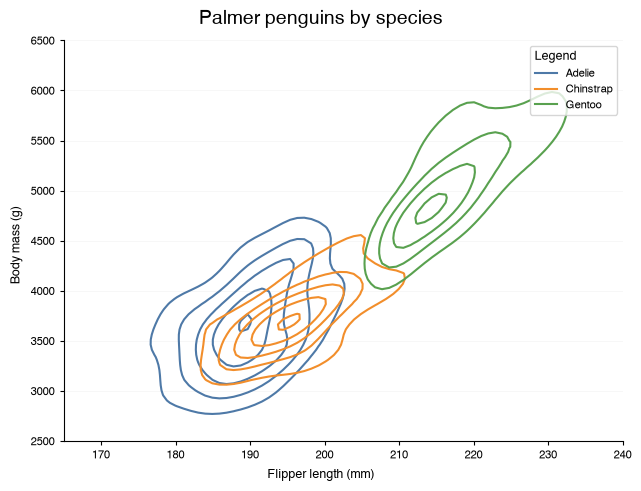

In [21]:
ContourChart(
    # use a list of surfaces to define multiple contour charts
    data=species_density,
    # one legend label per chart
    subtitle=SPECIES,
    show_legend=True,
    # the same number of levels on every surface
    levels=5,
    title="Palmer penguins by species",
    xlabel="Flipper length (mm)",
    ylabel="Body mass (g)",
    figsize=FIG_SIZE.FULL_MEDIUM,
).show()

### Subplots and shared axes

To draw each surface in its own subplot, add the `subplots` attribute. The `subtitle` becomes the subplot title and the `title`, `xlabel` and `ylabel` are positioned to be global for all charts. The `max_cols` attribute limits the number of columns, and `sharex` and `sharey` share an axis across the subplots; a shared axis is labeled once, on the outer subplots only. Per-chart attributes like `subtitle`, `style`, `valfmt`, `norm`, `vmin`, `vmax` and `colorbar` can be passed as lists, where each element corresponds to a chart; a single value applies to every chart.

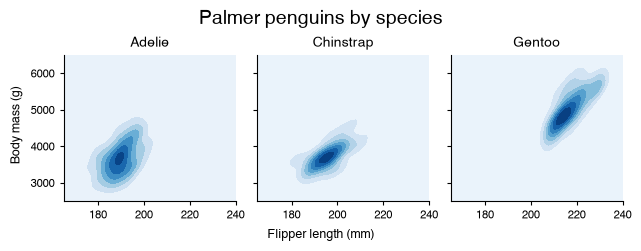

In [22]:
ContourChart(
    data=species_density,
    subtitle=SPECIES,
    # one filled subplot per species
    filled=True,
    subplots=True,
    max_cols=3,
    # the same axes for every species
    sharex=True,
    sharey=True,
    title="Palmer penguins by species",
    xlabel="Flipper length (mm)",
    ylabel="Body mass (g)",
    figsize=FIG_SIZE.FULL_SHORT,
).show()

### Emphasis

To draw attention to one surface among several, add the `emphasis` attribute. The `emphasis` list aligns with the charts of one call, and each entry is one of the following roles:

| Role | Description |
| :--- | :---------- |
| `"background"` | Mutes the iso-lines into the theme's muted color and alpha, behind the others, without a legend entry. |
| `"highlight"` | Bolds the iso-lines and brings them to the front. |
| `None` | Leaves the chart unchanged. |

A single value applies to every chart. Emphasis mutes and bolds lines, so it applies to iso-lines only; a filled contour takes the colormap and raises a `ValueError` when `emphasis` is passed. The [datachart.constants.EMPHASIS](../../../references/constants/#datachart.constants.EMPHASIS) constant holds the roles; the [highlighting guide](../../styling/highlighting.ipynb) covers emphasis across chart types and themes.

In [23]:
from datachart.constants import EMPHASIS

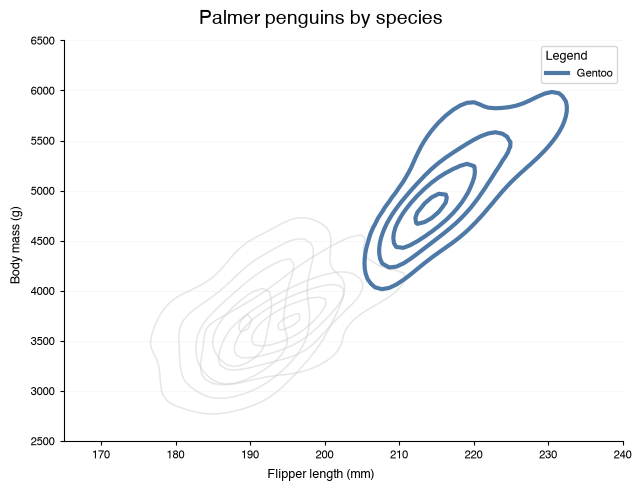

In [24]:
ContourChart(
    data=species_density,
    subtitle=SPECIES,
    # one role per chart: Adelie, Chinstrap, Gentoo
    emphasis=[EMPHASIS.BACKGROUND, EMPHASIS.BACKGROUND, EMPHASIS.HIGHLIGHT],
    show_legend=True,
    levels=5,
    title="Palmer penguins by species",
    xlabel="Flipper length (mm)",
    ylabel="Body mass (g)",
    figsize=FIG_SIZE.FULL_MEDIUM,
).show()

## Composing contours

A contour figure composes like any other chart. [datachart.utils.Panel](../../../references/utils/#datachart.utils.Panel) overlays it with other charts on shared axes — the natural pairing is a [datachart.charts.ScatterChart](../../../references/charts/#datachart.charts.ScatterChart) of the points behind a density, so the iso-lines show where the points concentrate. Every contour takes the next color of the panel's cycle, so the species stay distinct from the points.

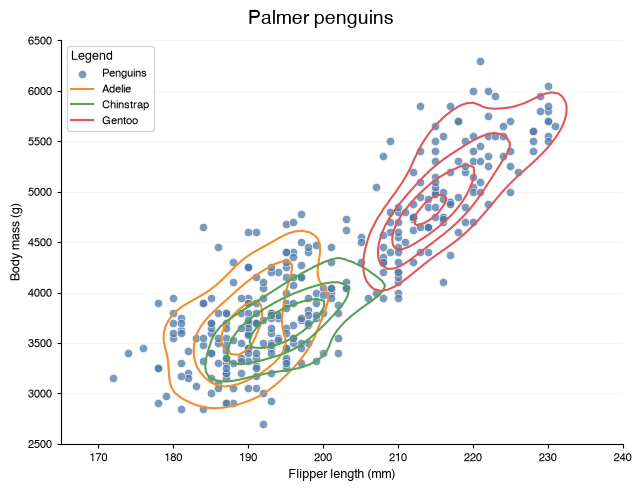

In [25]:
from datachart.charts import ScatterChart
from datachart.utils import Panel

Panel(
    [
        ScatterChart(data=penguin_points, subtitle="Penguins"),
        # the species densities, as iso-lines over the points
        ContourChart(data=species_density, subtitle=SPECIES, levels=4),
    ],
    title="Palmer penguins",
    xlabel="Flipper length (mm)",
    ylabel_left="Body mass (g)",
    show_legend=True,
    figsize=FIG_SIZE.FULL_MEDIUM,
).show()

[datachart.utils.Grid](../../../references/utils/#datachart.utils.Grid) arranges contour figures next to other figures. A filled contour of the Himmelblau function spans the top row; the species densities sit below it, next to the labeled iso-lines of the same function.

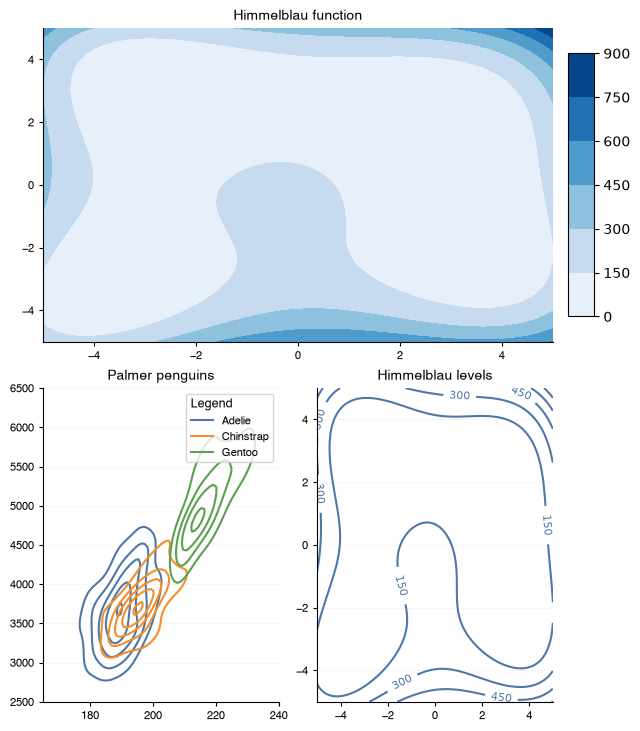

In [26]:
from datachart.utils import Grid

Grid(
    [
        [ContourChart(data=chart_data, filled=True, show_colorbars=True, title="Himmelblau function")],
        [
            ContourChart(data=species_density, subtitle=SPECIES, levels=5, show_legend=True, title="Palmer penguins"),
            ContourChart(data=chart_data, show_labels=True, valfmt=VALUE_FORMAT.INTEGER, title="Himmelblau levels"),
        ],
    ],
    figsize=FIG_SIZE.FULL_TALL,
).show()

## Additional Features

### Aspect ratio

By default the axes stretch to fill the figure, so a square grid may draw as a rectangle. To keep one unit equal on both axes, add the `aspect_ratio` attribute with a value of the [datachart.constants.ASPECT_RATIO](../../../references/constants/#datachart.constants.ASPECT_RATIO) constant — on a surface whose axes share a unit, like the Himmelblau function, the loops around the minima then keep their true shape.

In [27]:
from datachart.constants import ASPECT_RATIO

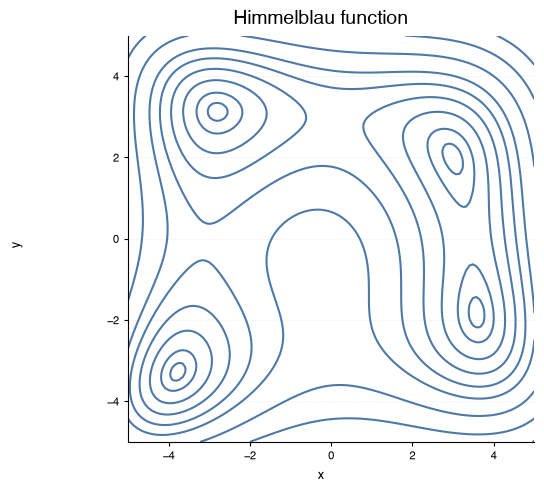

In [28]:
ContourChart(
    data=chart_data,
    # keep one unit equal on both axes
    aspect_ratio=ASPECT_RATIO.EQUAL,
    levels=[2, 10, 30, 60, 100, 150, 250, 400, 600],
    title="Himmelblau function",
    xlabel="x",
    ylabel="y",
    figsize=FIG_SIZE.FULL_MEDIUM,
).show()

### Reference lines

A reference line marks a position on the surface. To add vertical lines, add the `vlines` attribute with the [datachart.typings.VLinePlotAttrs](../../../references/typings/#datachart.typings.VLinePlotAttrs) typing, which is either a `dict` or a `List[dict]`; horizontal lines use `hlines` and the [datachart.typings.HLinePlotAttrs](../../../references/typings/#datachart.typings.HLinePlotAttrs) typing. Here the lines cross at the minimum of the Himmelblau function at (3, 2).

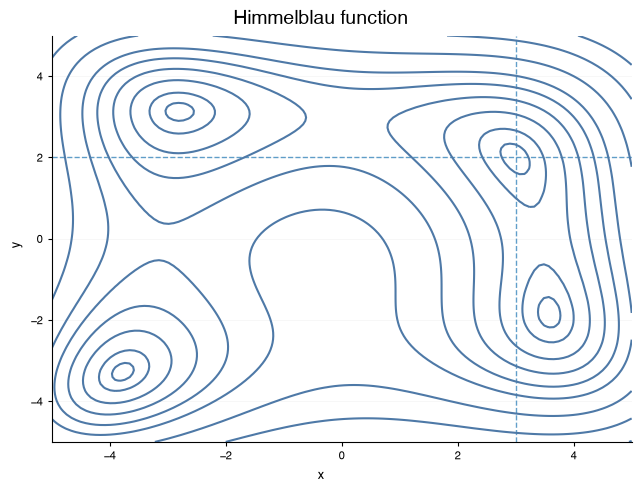

In [29]:
ContourChart(
    data=chart_data,
    # cross-hairs on the minimum at (3, 2)
    vlines={"x": 3, "style": {"plot_vline_style": LINE_STYLE.DASHED}},
    hlines={"y": 2, "style": {"plot_hline_style": LINE_STYLE.DASHED}},
    levels=[2, 10, 30, 60, 100, 150, 250, 400, 600],
    title="Himmelblau function",
    xlabel="x",
    ylabel="y",
    figsize=FIG_SIZE.FULL_MEDIUM,
).show()

### Density of scattered points

A contour chart of a density is the two-dimensional counterpart of a histogram: it shows where scattered points concentrate. [datachart.utils.stats.kde2d](../../../references/utils/stats/#datachart.utils.stats.kde2d) estimates that density with a Gaussian kernel and returns the `{x, y, z}` surface `ContourChart` takes, so there is no separate density chart — `ContourChart(kde2d(x, y))` is it. The `bandwidth` sets how smooth the estimate is: a [datachart.constants.BANDWIDTH](../../../references/constants/#datachart.constants.BANDWIDTH) rule (Scott's by default) or a scalar factor that replaces the rule, where smaller values follow the points more closely. The grid extends past the points by `cut` bandwidths, so the outer contours close instead of being clipped; `xlim` and `ylim` fix the grid instead, so several surfaces — the per-species densities of this guide — share one.

Here the density of all 342 penguins over their flipper length and body mass is drawn as filled bands, with a colorbar for the density; the [Composing contours](#composing-contours) section overlays the per-species densities on the points themselves.

In [30]:
from datachart.utils.stats import kde2d

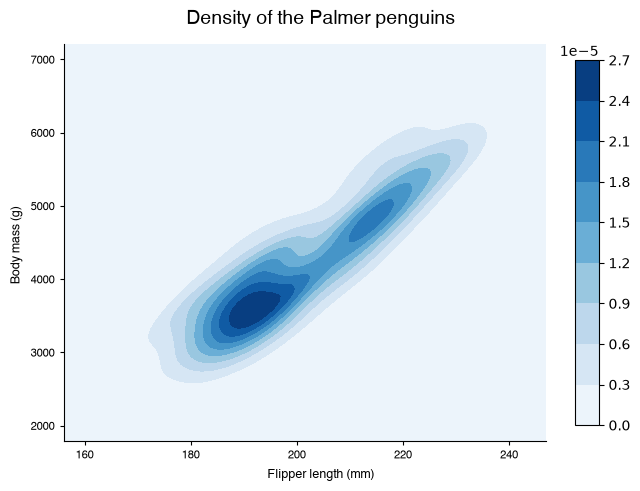

In [31]:
ContourChart(
    # the density of the penguins over flipper length and body mass
    data=kde2d(
        [point["x"] for point in penguin_points],
        [point["y"] for point in penguin_points],
    ),
    filled=True,
    show_colorbars=True,
    levels=8,
    title="Density of the Palmer penguins",
    xlabel="Flipper length (mm)",
    ylabel="Body mass (g)",
    figsize=FIG_SIZE.FULL_MEDIUM,
).show()

## Saving the Chart as an Image

To save the chart as an image, use the [datachart.utils.save_figure](../../../references/utils#datachart.utils.save_figure) function.

In [32]:
from datachart.utils import save_figure

figure = ContourChart(
    data=chart_data,
    filled=True,
    show_colorbars=True,
    title="Himmelblau function",
    xlabel="x",
    ylabel="y",
    figsize=FIG_SIZE.FULL_MEDIUM,
)
save_figure(figure, "./fig_contour_chart.png", dpi=300)

The figure should be saved in the current working directory.

## Real-World Examples

The following examples put the features above to work on real or realistic data. Each one states what its data is and where it comes from; the data itself lives in a hidden cell.

### Example 1: Optimizer Path on a Loss Landscape (Log Surface, Labels, and Panel)

`rosenbrock` samples the [Rosenbrock function](https://en.wikipedia.org/wiki/Rosenbrock_function), the standard test surface for optimizers: a long, curved, flat-bottomed valley with the minimum at (1, 1), which gradient methods find easily but converge along slowly. Its values span six orders of magnitude, so the surface is drawn as `log(1 + z)` — the log keeps the valley floor visible where the raw values would flatten everything but the rim. `descent` traces 2,000 steps of plain gradient descent from (−1.5, 2.5), computed in the hidden cell, every 40th step kept as a point: the path drops into the valley within a few steps, then crawls along its floor toward the minimum. A `Panel` overlays the path, a `LineChart` with markers, on the labeled iso-lines — pinned to the primary axis with `y_axis`, as the panel would otherwise put the narrow path on a secondary value axis; the levels follow the Freedman–Diaconis rule, denser than the default, so the narrow valley gets its own lines.

In [33]:
ROSEN_X = np.linspace(-2, 2, 120)
ROSEN_Y = np.linspace(-1, 3, 120)
RX, RY = np.meshgrid(ROSEN_X, ROSEN_Y)
rosenbrock = {
    "x": ROSEN_X.tolist(),
    "y": ROSEN_Y.tolist(),
    "z": np.log1p((1 - RX) ** 2 + 100 * (RY - RX**2) ** 2).tolist(),
}

# plain gradient descent on the Rosenbrock function
point = np.array([-1.5, 2.5])
descent = [{"x": float(point[0]), "y": float(point[1])}]
for step in range(1, 2001):
    x, y = point
    gradient = np.array([-2 * (1 - x) - 400 * x * (y - x**2), 200 * (y - x**2)])
    point = point - 0.001 * gradient
    if step % 40 == 0:
        descent.append({"x": float(point[0]), "y": float(point[1])})

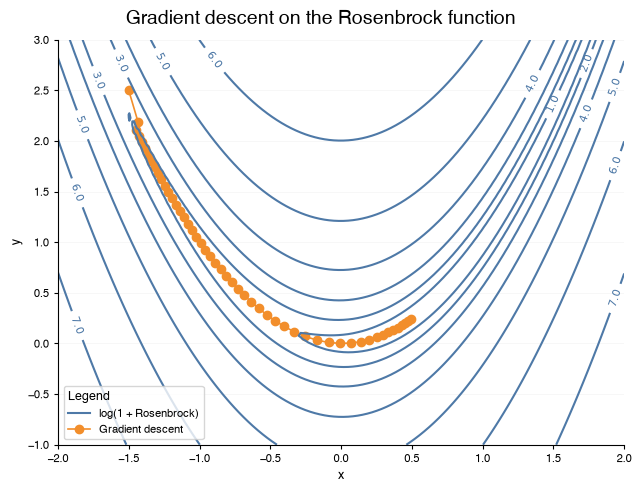

In [34]:
from datachart.charts import LineChart

Panel(
    [
        ContourChart(
            data=rosenbrock,
            subtitle="log(1 + Rosenbrock)",
            levels=CONTOUR_LEVELS.FD,
            show_labels=True,
            valfmt=VALUE_FORMAT.DECIMAL,
        ),
        {
            "figure": LineChart(
                data=descent,
                subtitle="Gradient descent",
                style={"plot_line_marker": "o", "plot_line_width": 1.2},
            ),
            # the path shares the surface's axes
            "y_axis": "left",
        },
    ],
    title="Gradient descent on the Rosenbrock function",
    xlabel="x",
    ylabel_left="y",
    show_legend=True,
    figsize=FIG_SIZE.FULL_MEDIUM,
).show()

### Example 2: Where the Species Overlap (Filled Subplots, Shared Levels, and Colorbars)

`species_density` from the multiple-charts section holds the density of each penguin species over flipper length and body mass. Drawn as filled subplots that share one explicit `levels` list — every chart is cut at the same values, so the same shade means the same density — the species are comparable: Gentoo penguins are heavier and longer-flippered than the other two, whose densities overlap almost entirely. A colorbar on each chart maps the shades back to the density, and `sharex` and `sharey` label the shared axes once.

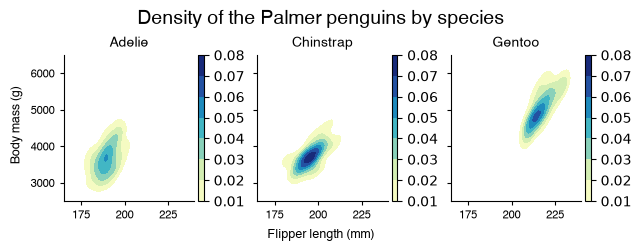

In [35]:
ContourChart(
    data=species_density,
    subtitle=SPECIES,
    filled=True,
    subplots=True,
    max_cols=3,
    sharex=True,
    sharey=True,
    # the same levels on every chart, so the shades are comparable
    levels=[0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08],
    show_colorbars=True,
    style={"plot_contour_cmap": COLORS.YlGnBu},
    title="Density of the Palmer penguins by species",
    xlabel="Flipper length (mm)",
    ylabel="Body mass (g)",
    figsize=FIG_SIZE.FULL_SHORT,
).show()